# COVID-19 Vaccine Rollout & Effectiveness — Exploratory Analysis

Two questions: (1) did vaccine rollout speed differ by country income level, and (2) did higher vaccination coverage going into the Delta wave predict lower mortality during it? Data: Our World in Data COVID-19 dataset, frozen subset (`data/raw/owid_covid_subset.csv`), Dec 2020 – Dec 2021.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
raw = pd.read_csv("../data/raw/owid_covid_subset.csv")
snapshot = pd.read_csv("../data/processed/country_snapshot.csv")
income_series = pd.read_csv("../data/processed/income_group_series.csv", parse_dates=["date"])
raw.shape, snapshot.shape

((68302, 11), (65, 8))

## Dataset overview

In [2]:
print(f"{raw['location'].nunique()} locations, {raw['date'].min()} to {raw['date'].max()}")
snapshot.describe()

168 locations, 2020-12-01 to 2021-12-31


,vax_rate_2021_07_01,median_age,gdp_per_capita,population,delta_wave_death_rate
count,65.000000,65.000000,65.000000,6.500000e+01,65.000000
mean,20.639538,34.918462,25491.335231,6.429913e+07,2.138669
std,17.630022,7.644318,20769.577985,1.816703e+08,2.058383
min,0.070000,17.700000,1899.780000,1.326064e+06,0.004565
25%,5.890000,29.300000,10849.300000,5.637022e+06,0.617609
50%,13.690000,34.100000,22767.040000,1.960374e+07,1.509891
75%,33.930000,41.800000,35220.080000,5.187403e+07,2.936848
max,67.320000,48.200000,116935.600000,1.417173e+09,9.862065


## Vaccine rollout speed by income group

OWID includes World Bank income-group aggregates directly as pseudo-location rows, so this uses the official aggregates rather than a self-derived grouping.

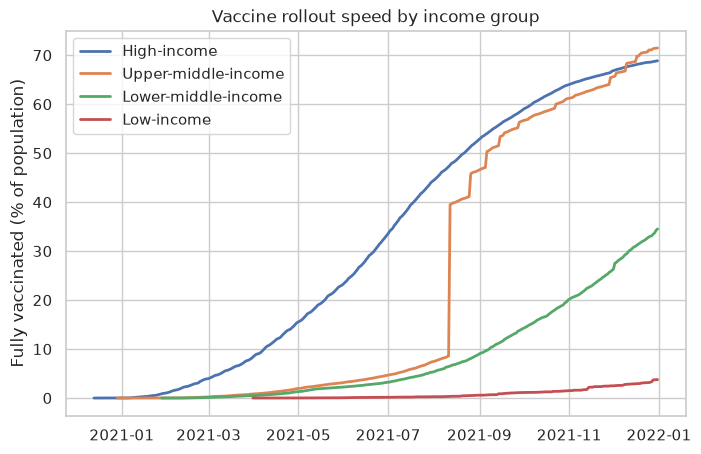

In [3]:
order = ["High-income countries", "Upper-middle-income countries",
         "Lower-middle-income countries", "Low-income countries"]
fig, ax = plt.subplots(figsize=(8, 5))
for group in order:
    sub = income_series[income_series["location"] == group].sort_values("date")
    ax.plot(sub["date"], sub["people_fully_vaccinated_per_hundred"], linewidth=2, label=group.replace(" countries", ""))
ax.set_ylabel("Fully vaccinated (% of population)")
ax.set_title("Vaccine rollout speed by income group")
ax.legend()
plt.show()

By the end of 2021, high- and upper-middle-income countries had fully vaccinated roughly two-thirds to three-quarters of their populations, lower-middle-income countries about a third, and low-income countries under 4% — a stark, persistent equity gap rather than a temporary lag.

## Wealth and vaccination coverage at the country level

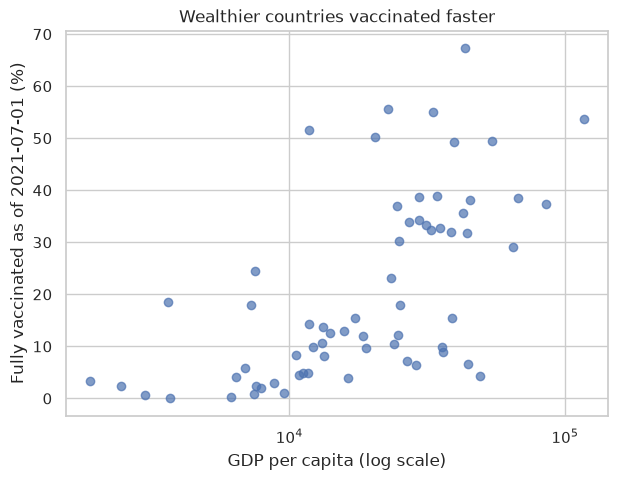

,gdp_per_capita,vax_rate_2021_07_01
gdp_per_capita,1.000000,0.580393
vax_rate_2021_07_01,0.580393,1.000000


In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(snapshot["gdp_per_capita"], snapshot["vax_rate_2021_07_01"], alpha=0.7)
ax.set_xscale("log")
ax.set_xlabel("GDP per capita (log scale)")
ax.set_ylabel("Fully vaccinated as of 2021-07-01 (%)")
ax.set_title("Wealthier countries vaccinated faster")
plt.show()
snapshot[["gdp_per_capita", "vax_rate_2021_07_01"]].corr(method="pearson")

## Vaccination coverage vs. subsequent Delta-wave mortality

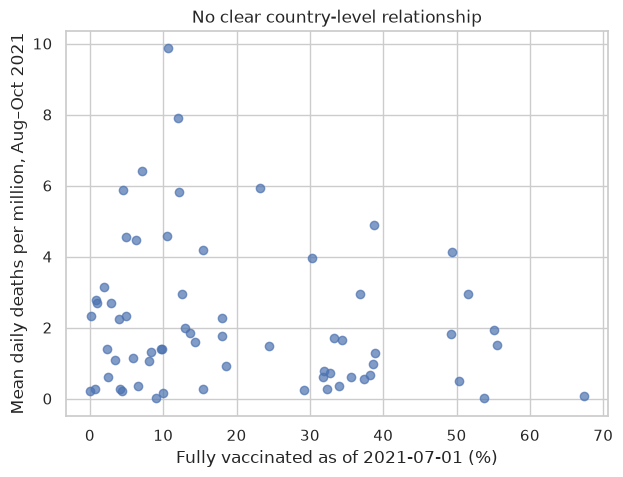

,vax_rate_2021_07_01,delta_wave_death_rate
vax_rate_2021_07_01,1.000000,-0.110271
delta_wave_death_rate,-0.110271,1.000000


In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(snapshot["vax_rate_2021_07_01"], snapshot["delta_wave_death_rate"], alpha=0.7)
ax.set_xlabel("Fully vaccinated as of 2021-07-01 (%)")
ax.set_ylabel("Mean daily deaths per million, Aug\u2013Oct 2021")
ax.set_title("No clear country-level relationship")
plt.show()
snapshot[["vax_rate_2021_07_01", "delta_wave_death_rate"]].corr(method="spearman")

Unlike the wealth-vaccination relationship above, vaccination coverage shows no visually obvious relationship with subsequent Delta-wave mortality at the country level — see `results/regression_results.json` and the project README for the formal correlation/regression test and a discussion of why an aggregate,
country-level design is a weak instrument for detecting vaccine effectiveness, compared to individual-level clinical evidence.